In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from const import *

plt.style.use('default') # 重置
params = {
    'font.family': 'serif',        # 衬线体 (Times New Roman 等)
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'], # 显式指定
    'mathtext.fontset': 'stix',    # 数学公式字体更像 LaTeX
    'axes.labelsize': 14,
    'font.size': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.spines.top': False,      # 去掉顶部边框 (更简洁)
    'axes.spines.right': False,    # 去掉右侧边框
}
plt.rcParams.update(params)

In [2]:
from utilize.mesh_io import read_mshv2_triangular

node_pos_np, triangles = read_mshv2_triangular("pd_stretch_tissue_mesh_init.msh")

updated_w = np.loadtxt(f"stretch_weight_update.csv", delimiter=",") 

high_uncertainty_indices_gn = np.loadtxt(f"high_uncertainty_indices_gn.csv", delimiter=",", dtype=int)

high_uncertainty_mask_gn = np.zeros(triangles.shape[0], dtype=bool)
high_uncertainty_mask_gn[high_uncertainty_indices_gn] = True

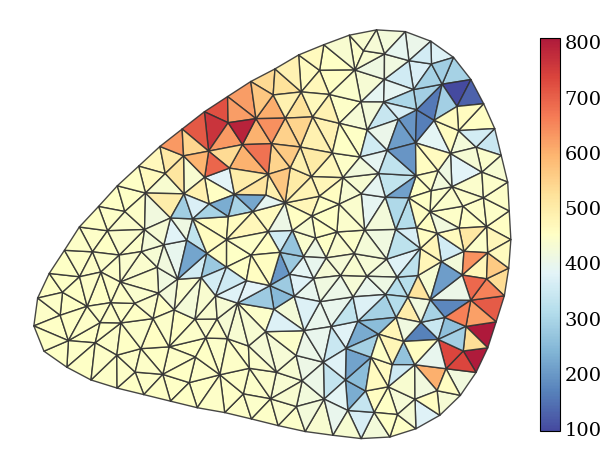

In [3]:
cmap_custom = sns.color_palette("RdYlBu_r", as_cmap=True)

# 可视化刚度值
raw_k = updated_w.copy()
v_min, v_max = raw_k.min(), raw_k.max()
tick_locs = np.arange(np.ceil((v_min)), np.floor((v_max)))
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles,
                    facecolors=raw_k, shading='flat', 
                    edgecolors='#333333', linewidth=1., alpha=0.9, cmap=cmap_custom)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.046)
cbar1.ax.tick_params(length=0, labelsize=14)

# cbar1.set_ticks(tick_locs)
# cbar1.set_ticklabels([f"$10^{{ {int(loc):d} }}$" for loc in tick_locs])

plt.savefig(f"stiffness_value_gn.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

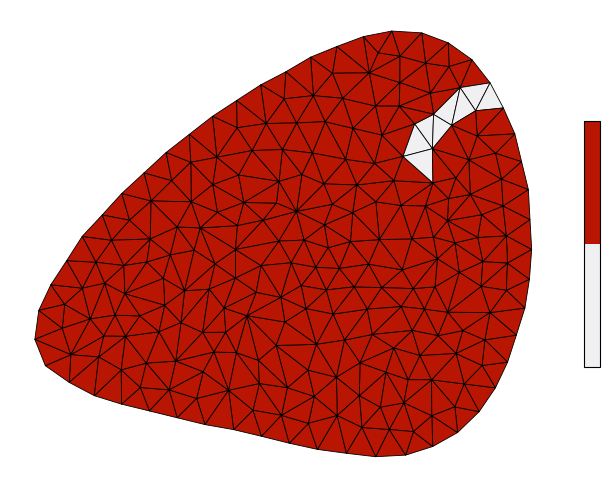

In [4]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=high_uncertainty_mask_gn.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region_variance.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

[Field Metric 1] ROC-AUC: 0.5474 (Closer to 1.0 is better)  
[Field Metric 2] Average Precision (PR-AUC): 0.0948 (Higher is better)  
[Field Metric 3] GT-based Log-CNR: 0.1115 (Higher means better signal contrast)  
[Field Metric 4] GT-based FDR: 0.0122 (Higher means better statistical separability)  
[Field Metric 5] GT-based Suppression Ratio: 700429985196916176610599935780728075978302672985265518887829504.0000 (Higher means target is relatively enhanced)  
[Field Metric 5] GT-based Log Suppression Ratio: 62.8454